# Experiment 07 – Supervised Classification

## Aim

To build supervised classification models for predicting diabetes outcomes using the Pima Indians Diabetes Dataset and evaluate their performance using appropriate classification metrics.

## Objectives

1. Build supervised classification models to predict the diabetes outcome of patients.
2. Evaluate and interpret classification model performance using appropriate evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)
sns.set_theme(style="whitegrid")

In [2]:
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
df_processed = df.copy()
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df_processed[invalid_columns] = df_processed[invalid_columns].replace(0, np.nan)
for column in invalid_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )
print("Invalid values handled successfully.")
print("\nRemaining missing values:")
print(df_processed.isnull().sum())

Invalid values handled successfully.

Remaining missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
X = df_processed[features]
y = df_processed["Outcome"]
print("Features:")
print(features)
print("\nTarget:")
print("Outcome")

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (614, 8)
Testing set shape: (154, 8)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "k-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    )
}
print("Classification models defined successfully.")

Classification models defined successfully.


In [8]:
results = []

predictions = {}
probabilities = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296
1,k-Nearest Neighbors,0.811688,0.735849,0.722222,0.728972,0.863148
2,Decision Tree,0.824675,0.754717,0.740741,0.747664,0.912130


In [9]:
for name in models:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["Non-diabetic", "Diabetic"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

Non-diabetic       0.77      0.79      0.78       100
    Diabetic       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

k-Nearest Neighbors
              precision    recall  f1-score   support

Non-diabetic       0.85      0.86      0.86       100
    Diabetic       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

Decision Tree
              precision    recall  f1-score   support

Non-diabetic       0.86      0.87      0.87       100
    Diabetic       0.75      0.74      0.75        54

    accuracy                           0.82       154
   macro avg       0.81      0.81      0.81       154
weighted avg       0

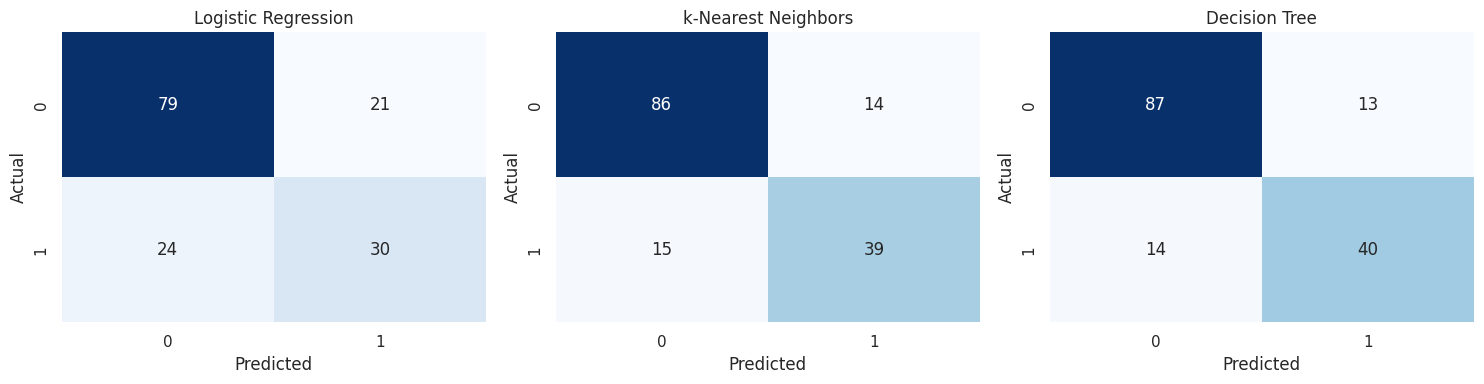

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

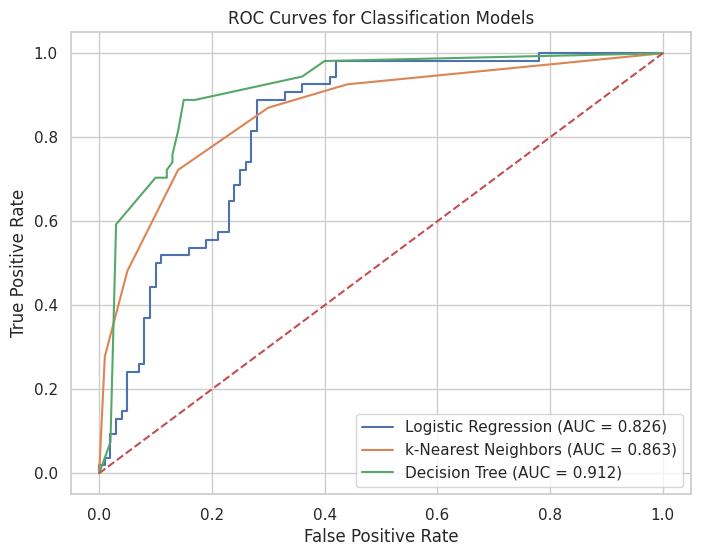

In [11]:
plt.figure(figsize=(8, 6))
for name in models:
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.show()

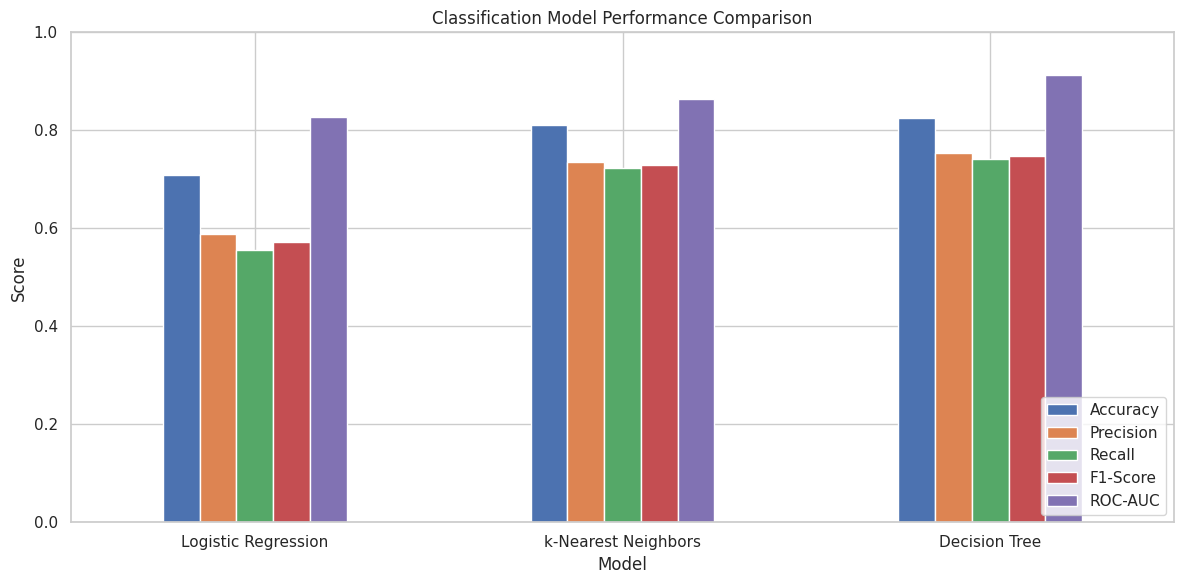

In [12]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]
results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusion

Supervised classification models were developed to predict diabetes outcomes using the Pima Indians Diabetes Dataset.

Logistic Regression, k-Nearest Neighbors, and Decision Tree models were trained and evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

The evaluation metrics provide different perspectives on classification performance, allowing the models to be compared across multiple measures.